In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [6]:
df = pd.read_csv("CarPrice_Assignment.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


# Анализ

In [7]:
print(df.shape)
display(df.info())
display(df.isna().sum().sort_values(ascending=False).head(10))

(205, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    

None

car_ID              0
symboling           0
highwaympg          0
citympg             0
peakrpm             0
horsepower          0
compressionratio    0
stroke              0
boreratio           0
fuelsystem          0
dtype: int64

In [8]:
df = df.drop(columns=["car_ID"])

In [9]:
target_col = "price"

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = df.select_dtypes(exclude=["object"]).columns.tolist()

numeric_cols.remove(target_col)

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Categorical: ['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']
Numeric: ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']


In [10]:
X = df.drop(columns=[target_col])
y = df[target_col].copy()

print(X.shape, y.shape)

(205, 24) (205,)


In [12]:
# Проверить, что никакие колонки не потерялись
X.shape[1] + 1 == df.shape[1]

True

In [13]:
X["CompanyName"] = X["CarName"].str.split(" ", n=1).str[0].str.lower()
X["CarModel"] = X["CarName"].str.split(" ", n=1).str[1].fillna("").str.lower()
X[["CarName", "CompanyName", "CarModel"]].head(10)

,CarName,CompanyName,CarModel
0,alfa-romero giulia,alfa-romero,giulia
1,alfa-romero stelvio,alfa-romero,stelvio
2,alfa-romero Quadrifoglio,alfa-romero,quadrifoglio
3,audi 100 ls,audi,100 ls
4,audi 100ls,audi,100ls
5,audi fox,audi,fox
6,audi 100ls,audi,100ls
7,audi 5000,audi,5000
8,audi 4000,audi,4000
9,audi 5000s (diesel),audi,5000s (diesel)


In [14]:
X = X.drop(columns=["CarName"])

In [15]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Categorical: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'CompanyName', 'CarModel']
Numeric: ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']


In [16]:
X["CompanyName"].value_counts().head(30)

CompanyName
toyota         31
nissan         18
mazda          15
honda          13
mitsubishi     13
subaru         12
peugeot        11
volvo          11
dodge           9
volkswagen      9
bmw             8
buick           8
audi            7
plymouth        7
saab            6
isuzu           4
porsche         4
alfa-romero     3
jaguar          3
chevrolet       3
vw              2
maxda           2
renault         2
toyouta         1
vokswagen       1
mercury         1
porcshce        1
Name: count, dtype: int64

In [17]:
company_fix = {
    "vokswagen": "volkswagen",
    "vw": "volkswagen",
    "toyouta": "toyota",
    "maxda": "mazda",
    "porcshce": "porsche",
}

X["CompanyName"] = X["CompanyName"].replace(company_fix)
X["CompanyName"].value_counts().head(30)

CompanyName
toyota         32
nissan         18
mazda          17
mitsubishi     13
honda          13
volkswagen     12
subaru         12
peugeot        11
volvo          11
dodge           9
buick           8
bmw             8
audi            7
plymouth        7
saab            6
porsche         5
isuzu           4
jaguar          3
chevrolet       3
alfa-romero     3
renault         2
mercury         1
Name: count, dtype: int64

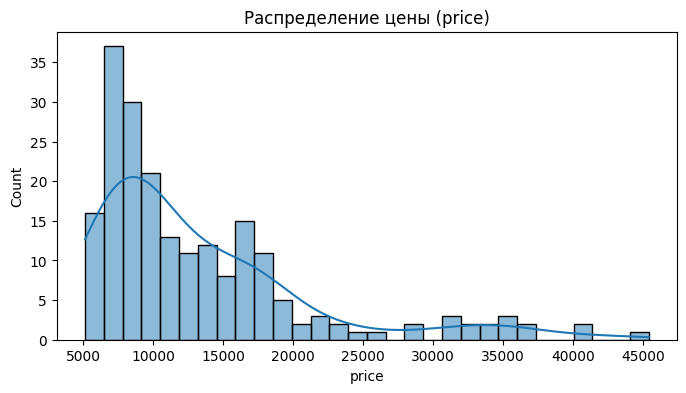

In [18]:
plt.figure(figsize=(8, 4))
sns.histplot(y, bins=30, kde=True)
plt.title("Распределение цены (price)")
plt.xlabel("price")
plt.show()

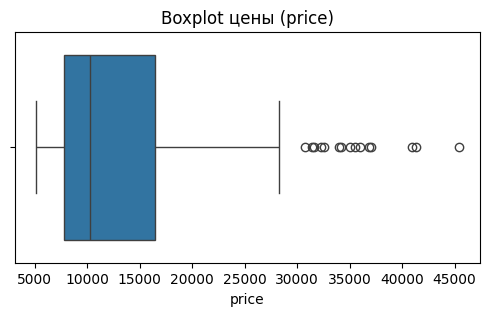

In [20]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=y)
plt.title("Boxplot цены (price)")
plt.xlabel("price")
plt.show()

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(164, 25) (41, 25)


# Предобработка

In [24]:
categorical_transformer = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1)

preprocess_no_scale = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False)

preprocess_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False)

# Обучение + подбор гиперпараметров

In [25]:
# GridSearchCV для подбора гиперпараметров
def run_grid(model, param_grid, preprocessor, X_train, y_train, X_test, y_test, cv=5):
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    gs = GridSearchCV(
        pipe,
        param_grid=param_grid,
        cv=cv,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )
    gs.fit(X_train, y_train)
    
    best_model = gs.best_estimator_
    preds = best_model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    return {
        "best_params": gs.best_params_,
        "cv_best_mse": -gs.best_score_,
        "test_mse": mse,
        "test_r2": r2,
        "estimator": best_model
    }

### 1. Linear Regression (без регуляризации) 

In [26]:
lr = LinearRegression()

lr_grid = {
    "model__fit_intercept": [True, False],
    "model__positive": [False, True],
}

res_lr_no_scale = run_grid(lr, lr_grid, preprocess_no_scale, X_train, y_train, X_test, y_test)
res_lr_scaled   = run_grid(lr, lr_grid, preprocess_scaled,   X_train, y_train, X_test, y_test)

res_lr_no_scale, res_lr_scaled

Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/1k/9px7zqq15jb39nmtr638216h0000gn/T/joblib_memmapping_folder_46386_58891ed47a9b4ffdbee72c421a2afb78_518caa72e81d45f88547e7b0bb51f100 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-46386-5kmteqc4 for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
 

({'best_params': {'model__fit_intercept': True, 'model__positive': False},
  'cv_best_mse': np.float64(9172087.909992952),
  'test_mse': 15152817.88935865,
  'test_r2': 0.8080561678957597,
  'estimator': Pipeline(steps=[('preprocess',
                   ColumnTransformer(transformers=[('num', 'passthrough',
                                                    ['symboling', 'wheelbase',
                                                     'carlength', 'carwidth',
                                                     'carheight', 'curbweight',
                                                     'enginesize', 'boreratio',
                                                     'stroke', 'compressionratio',
                                                     'horsepower', 'peakrpm',
                                                     'citympg', 'highwaympg']),
                                                   ('cat',
                                                    OrdinalEncoder(handle_

### 2. Ridge (L2)

In [28]:
ridge = Ridge(random_state=42)

ridge_grid = {
    "model__alpha": np.logspace(-3, 3, 25),
    "model__fit_intercept": [True, False],
    "model__solver": ["auto", "svd", "cholesky", "lsqr", "sag", "saga"],
}

res_ridge_no_scale = run_grid(ridge, ridge_grid, preprocess_no_scale, X_train, y_train, X_test, y_test)
res_ridge_scaled   = run_grid(ridge, ridge_grid, preprocess_scaled,   X_train, y_train, X_test, y_test)

res_ridge_no_scale, res_ridge_scaled

Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/1k/9px7zqq15jb39nmtr638216h0000gn/T/joblib_memmapping_folder_46386_776875445a8b466086259adb84479731_60b0d560a3c349e0bc8c008a6876df53 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/1k/9px7zqq15jb39nmtr638216h0000gn/T/joblib_memmapping_folder_46386_58891ed47a9b4ffdbee72c421a2afb

({'best_params': {'model__alpha': np.float64(0.31622776601683794),
   'model__fit_intercept': True,
   'model__solver': 'svd'},
  'cv_best_mse': np.float64(8847989.923176432),
  'test_mse': 14025952.107299868,
  'test_r2': 0.8223304063941582,
  'estimator': Pipeline(steps=[('preprocess',
                   ColumnTransformer(transformers=[('num', 'passthrough',
                                                    ['symboling', 'wheelbase',
                                                     'carlength', 'carwidth',
                                                     'carheight', 'curbweight',
                                                     'enginesize', 'boreratio',
                                                     'stroke', 'compressionratio',
                                                     'horsepower', 'peakrpm',
                                                     'citympg', 'highwaympg']),
                                                   ('cat',
                    

### 3. Lasso (L1)

In [30]:
lasso = Lasso(random_state=42)

lasso_grid = {
    "model__alpha": np.logspace(-4, 2, 25),
    "model__fit_intercept": [True, False],
    "model__max_iter": [2000, 5000, 10000],
}

res_lasso_no_scale = run_grid(lasso, lasso_grid, preprocess_no_scale, X_train, y_train, X_test, y_test)
res_lasso_scaled   = run_grid(lasso, lasso_grid, preprocess_scaled,   X_train, y_train, X_test, y_test)

res_lasso_no_scale, res_lasso_scaled

Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/1k/9px7zqq15jb39nmtr638216h0000gn/T/joblib_memmapping_folder_46386_35f9cffee70440d2a3841c284980f2d2_aa7eb024e9ff4b308775b4b4e34a9bc9 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/1k/9px7zqq15jb39nmtr638216h0000gn/T/joblib_memmapping_folder_46386_58891ed47a9b4ffdbee72c421a2afb

({'best_params': {'model__alpha': np.float64(31.622776601683793),
   'model__fit_intercept': True,
   'model__max_iter': 2000},
  'cv_best_mse': np.float64(8558835.196792323),
  'test_mse': 13373693.575437214,
  'test_r2': 0.8305926981370244,
  'estimator': Pipeline(steps=[('preprocess',
                   ColumnTransformer(transformers=[('num', 'passthrough',
                                                    ['symboling', 'wheelbase',
                                                     'carlength', 'carwidth',
                                                     'carheight', 'curbweight',
                                                     'enginesize', 'boreratio',
                                                     'stroke', 'compressionratio',
                                                     'horsepower', 'peakrpm',
                                                     'citympg', 'highwaympg']),
                                                   ('cat',
                    

### Результаты

In [33]:
results = []

def add_result(name, scaling, res):
    results.append({
        "model": name,
        "scaling": scaling,
        "cv_best_mse": res["cv_best_mse"],
        "test_mse": res["test_mse"],
        "test_r2": res["test_r2"],
    })

add_result("LinearRegression", "no_scale", res_lr_no_scale)
add_result("LinearRegression", "scaled",   res_lr_scaled)

add_result("Ridge (L2)", "no_scale", res_ridge_no_scale)
add_result("Ridge (L2)", "scaled",   res_ridge_scaled)

add_result("Lasso (L1)", "no_scale", res_lasso_no_scale)
add_result("Lasso (L1)", "scaled",   res_lasso_scaled)

results_df = pd.DataFrame(results).sort_values(by="test_mse")
results_df

,model,scaling,cv_best_mse,test_mse,test_r2
5,Lasso (L1),scaled,8.536151e+06,1.319516e+07,0.832854
4,Lasso (L1),no_scale,8.558835e+06,1.337369e+07,0.830593
3,Ridge (L2),scaled,8.807899e+06,1.398292e+07,0.822875
2,Ridge (L2),no_scale,8.847990e+06,1.402595e+07,0.822330
0,LinearRegression,no_scale,9.172088e+06,1.515282e+07,0.808056
1,LinearRegression,scaled,9.012773e+06,1.568820e+07,0.801274


Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-46386-et_lboja for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-46386-6o1w8udt for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/reso

# Выводы

Проведена подготовка данных согласно заданию: удалён car_ID, целевая переменная price отделена, CarName разделён на CompanyName и CarModel, исправлены опечатки производителей

Реализованы два варианта предобработки: без нормализации и со StandardScaler для числовых признаков. Категориальные признаки закодированы OrdinalEncoder с обработкой неизвестных категорий

Обучены и сравнены модели LinearRegression, Ridge (L2) и Lasso (L1) с подбором гиперпараметров через GridSearchCV

По итогам сравнения лучшая модель определяется по минимальному test_mse (и дополнительно учитывается test_r2). Как правило, регуляризованные модели (особенно при scaling) дают более стабильное качество и лучше обобщают
